# Intro
This notebook will build a GCN  + GRU model to predict station demand at timestep T. This will be based off a flow based adjacency between stations to construct our adjacency matrix.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os, shutil, subprocess

WORK_DIR = '/content/drive/MyDrive/DL_Project'
os.chdir(WORK_DIR)
print('cwd:', os.getcwd())

Mounted at /content/drive
cwd: /content/drive/MyDrive/DL_Project


In [2]:
%pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.1 MB/s eta 0:00:00a 0:00:01


In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # make cuda error synchonous

In [4]:
import polars as pl
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


from torch_geometric.nn.conv import GCNConv


# Data readin

In [5]:
# read in cabi data
cabi = pl.read_parquet('data/cabi_combined_data.parquet').with_columns([
    pl.col("start_station_id").cast(pl.Int64),
    pl.col("end_station_id").cast(pl.Int64),
])

In [6]:
cabi.head(10)

ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,_source_zip,_source_file
str,str,str,str,str,i64,str,i64,f64,f64,f64,f64,str,str,str
"""1B4445D591115BD9""","""classic_bike""","""2022-01-06 18:39:28""","""2022-01-06 18:43:03""","""Monroe Ave & Leslie Ave""",31087,"""Potomac Ave & Main Line Blvd""",31910,38.820932,-77.053096,38.822738,-77.049265,"""member""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""7F4A0E2F03EADEB7""","""classic_bike""","""2022-01-31 19:21:22""","""2022-01-31 19:27:33""","""14th & L St NW""",31283,"""10th & G St NW""",31274,38.903658,-77.031737,38.898243,-77.026235,"""member""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""30DD8A84164843AD""","""classic_bike""","""2022-01-07 15:28:39""","""2022-01-07 15:31:01""","""14th & L St NW""",31283,"""12th & L St NW""",31251,38.903658,-77.031737,38.903819,-77.0284,"""member""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""FC67665D7682D0A6""","""classic_bike""","""2022-01-27 20:09:25""","""2022-01-27 20:37:02""","""New York Ave & Hecht Ave NE""",31518,"""Nannie Helen Burroughs & Minne…",31704,38.915604,-76.983683,38.901385,-76.941877,"""casual""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""7854F7CC4F631A1E""","""classic_bike""","""2022-01-07 16:14:28""","""2022-01-07 16:16:13""","""Falls Church City Hall / Park …",32608,"""Pennsylvania Ave & Park Ave""",32603,38.885434,-77.173605,38.887403,-77.176992,"""member""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""FBDCB4296C2A0B2E""","""classic_bike""","""2022-01-24 19:50:35""","""2022-01-24 20:07:00""","""14th & L St NW""",31283,"""Park Rd & Holmead Pl NW""",31602,38.903658,-77.031737,38.9308,-77.0315,"""casual""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""6B14178CB767703A""","""classic_bike""","""2022-01-26 19:37:48""","""2022-01-26 19:48:50""","""Adams Mill & Columbia Rd NW""",31104,"""3rd & Elm St NW""",31118,38.922925,-77.042581,38.917622,-77.01597,"""casual""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""390C77E802B77D91""","""classic_bike""","""2022-01-15 10:12:52""","""2022-01-15 10:22:15""","""14th & Harvard St NW""",31105,"""11th & S St NW""",31280,38.9268,-77.0322,38.913761,-77.027025,"""member""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"
"""131937550248E68C""","""electric_bike""","""2022-01-08 11:48:59""","""2022-01-08 11:56:21""","""14th & Harvard St NW""",31105,"""Calvert St & Woodley Pl NW""",31121,38.926775,-77.032137,38.923583,-77.050046,"""casual""","""202201-capitalbikeshare-tripda…","""202201-capitalbikeshare-tripda…"


# Construct Flow Adjacency

In [7]:
# convert these to int since the code below won't work otherwise
cabi = cabi.with_columns([
    pl.col("start_station_id").cast(pl.Int64),
    pl.col("end_station_id").cast(pl.Int64)
])

In [8]:
# compute bidirectional step counts between stations

flow_df = cabi.filter(pl.col("start_station_id").is_not_null() &
            pl.col("end_station_id").is_not_null() &
            pl.col("start_station_id") != pl.col("end_station_id")
            ).select(["start_station_id", "end_station_id"]
            ).with_columns([
                # compute as directed edge
               pl.min_horizontal("start_station_id", "end_station_id").alias("source"),
                pl.max_horizontal("start_station_id", "end_station_id").alias("dest")
            ]).group_by(["source", "dest"]).agg(pl.len().alias("flow"))


In [9]:
# make adjacency list symmetric
forward = flow_df.rename({"source": "station", "dest": "neighbor"})
backward = flow_df.rename({"source": "station", "dest": "neighbor"})

adj = pl.concat([forward, backward])

In [10]:
# filter for only top 5 neighbors or top k
K = 5
top_k = adj.sort("flow", descending=True
                 ).group_by("station"
                ).head(K
                ).sort(
                ["station", "flow"],
                descending=[False, True]
                )

In [11]:
# and delete our original data
cabi = cabi.clear()
import gc
gc.collect()

0

# Data Prep
Now that we have tha adjacency matrix, lets pump that into our nodes with our main dataset as well

In [12]:
cabi_demand = pl.read_parquet("data/cabi_master.parquet").with_columns([
    pl.col("start_station_id").cast(pl.Int64),
])

# establish min rows to remove sparse stations
min_rows = 1000
station_counts = cabi_demand.with_columns(
    pl.col("start_station_id").cast(pl.Int64)
).group_by("start_station_id").agg(
    pl.len().alias("n_rows")
).filter(pl.col("n_rows") >= min_rows)

valid_stations = set(station_counts["start_station_id"].to_list())

cabi_demand = cabi_demand.with_columns(
    pl.col("start_station_id").cast(pl.Int64)
).filter(pl.col("start_station_id").is_in(valid_stations))

valid_stations = set(station_counts["start_station_id"].to_list())

In [13]:
cabi_demand.head(5)

start_station_id,year,started_at_15,demand,latitude,longitude,n_nearby_stations,n_bus_stops,n_metro_stations,n_commuter_bus,n_tourist_bus,n_carshare,n_hotels,n_museums,n_recreation,n_shopping,n_universities,n_schools,n_schools_private,n_parks,n_national_parks,m5_4_bike_,m5_5_sidew,m8_3_trail,m8_4_land_,m8_5_posit,m8_6_flood,m9_1_vacan,m9_2_stree,m9_3_polic,m9_4_fire_,m9_5_HIN,m6_5_resta,m6_6_liquo,m8_1_urban,total_popE,pop_maleE,pop_femaleE,median_ageE,median_hh_incomeE,in_low_stress_bikeshed,in_total_bikeshed,temp_f,precip_in,hour,minute,day_of_week,month,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos,date,is_holiday
i64,f64,"datetime[μs, UTC]",i32,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64,date,i8
30200,2024.0,2023-02-01 15:15:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,38.3,0.0,15,15,3,2,5,0,0.433884,-0.900969,0.568065,0.822984,2023-02-01,0
30200,2024.0,2023-02-01 16:15:00 UTC,0,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,38.1,0.0,16,15,3,2,5,0,0.433884,-0.900969,0.568065,0.822984,2023-02-01,0
30200,2024.0,2023-02-01 16:30:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,38.1,0.0,16,30,3,2,5,0,0.433884,-0.900969,0.568065,0.822984,2023-02-01,0
30200,2024.0,2023-02-02 08:45:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,29.2,0.0,8,45,4,2,5,0,-0.433884,-0.900969,0.568065,0.822984,2023-02-02,0
30200,2024.0,2023-02-02 11:15:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,35.1,0.0,11,15,4,2,5,0,-0.433884,-0.900969,0.568065,0.822984,2023-02-02,0


## Build Edge Index
A GNN is made of nodes and edges, we can use our adjacency matrix as our weighted edge index.

In [14]:
# get all station ids
# need to convert to integer since we did that for everything before
station_ids = cabi_demand.with_columns([pl.col("start_station_id").cast(pl.Int64)]
                                ).select("start_station_id"
                                 ).unique(
                                ).sort("start_station_id"
                                ).get_column("start_station_id"
                                ).to_list()


# convert to an integer index
station_idx_mapper = {si: i for i, si in enumerate(station_ids)}
N = len(station_ids)
# map station ids to the stations / neighors
edges = top_k.with_columns([
    pl.col("station").cast(pl.Int64),
    pl.col("neighbor").cast(pl.Int64),
]).with_columns([
     pl.col("station").map_elements(lambda x: station_idx_mapper.get(x, None), return_dtype=pl.Int64).alias("src_idx"),
    pl.col("neighbor").map_elements(lambda x: station_idx_mapper.get(x, None), return_dtype=pl.Int64).alias("dst_idx"),
]).select(["src_idx", "dst_idx", "flow"]).drop_nulls()
# convert to torch tensors
# get sources
source = torch.tensor(edges["src_idx"].to_list(), dtype=torch.long)
#get destinations
dst = torch.tensor(edges["dst_idx"].to_list(), dtype=torch.long)
# combine into a complete stacked edge index
edge_index = torch.stack([source, dst], dim=0)

# Normalize weights from 0 to 1
flow = torch.tensor(edges["flow"].to_list(), dtype=torch.float)
edge_data = (flow / flow.max()).unsqueeze(1)
print("edge data shape")
print(edge_data.shape)
print("edge index shape")
print(edge_index.shape)



edge data shape
torch.Size([1942, 1])
edge index shape
torch.Size([2, 1942])


## Build Feature Tensor from cabi_demand
As we get into this we need to pivot some of our features to work with this new thing. We will first want to split up our station specific featurs from our time based ones.This will help later in our modeling.

In [15]:
# Establish our 2 feature sets
static_feat = [
    "n_bus_stops", "n_metro_stations", "n_commuter_bus", "n_carshare",
    "n_hotels", "n_parks", "n_shopping", "total_popE", "median_hh_incomeE",
    "in_low_stress_bikeshed", "latitude", "longitude",
    "m5_4_bike_", "m5_5_sidew", "m8_3_trail", "m8_1_urban",
]
# time based, this needs to only be repeated on our temporal layer
time_feat = [
    "temp_f", "precip_in",
    "hour", "minute",
    "day_of_week_sin", "day_of_week_cos",
    "week_of_year_sin", "week_of_year_cos",
    # "is_weekend", "is_holiday",
    "month",
]

all_feat = static_feat + time_feat


In [16]:
# lets sort our timesteps
distinct_timesteps = cabi_demand.select("started_at_15"
                                    ).unique().sort("started_at_15"
                                    ).get_column("started_at_15").to_list()
T = len(distinct_timesteps)
# get our mapper here as well
timestep_mapper = {t: i for i, t in enumerate(distinct_timesteps)}

In [17]:
# Pivot over from wide to long dense arrays
# First make empty zero arrays for missing timesteps and such
F = len(all_feat)
x = np.zeros((N, T, F), dtype=np.float32)
y = np.zeros((N,T), dtype=np.float32)
# select columns and add index
# this needs to be an integer).with_columns([
demand_selected = cabi_demand.with_columns(
    [pl.col("start_station_id").cast(pl.Int64)]
    ).with_columns([
        pl.col("start_station_id").replace(station_idx_mapper).cast(pl.Int64).alias("node_idx"),
        pl.col("started_at_15").replace(timestep_mapper).cast(pl.Int64).alias("time_idx"),
]).select(["node_idx", "time_idx", "demand"] + all_feat
          ).drop_nulls() # also drop any nulls  we see

# extract our indexs and values for them
node_idx = demand_selected["node_idx"].to_numpy().astype(np.int64)
time_idx = demand_selected["time_idx"].to_numpy().astype(np.int64)
feat_vals = demand_selected.select(all_feat).to_numpy()
demand_vals = demand_selected["demand"].to_numpy()

# to tensors!

x[node_idx, time_idx, :] = feat_vals
y[node_idx, time_idx] = demand_vals
x = torch.tensor(x, dtype=torch.float)
y = torch.tensor(y, dtype = torch.float)


In [18]:
# check shapes
print("x shape")
print(x.shape)
print("y shape")
print(y.shape)

x shape
torch.Size([407, 148271, 25])
y shape
torch.Size([407, 148271])


In [19]:
# Build per-station active mask: True where the station was operational
# Active window = first_seen to last_seen for each station in the trips data.
# Cells inside the window with no row are real zeros (no trips that 15-min);
# cells outside the window are genuinely missing (station didn't exist yet or was decommissioned).

station_active = cabi_demand.group_by("start_station_id").agg([
    pl.col("started_at_15").min().alias("first_seen"),
    pl.col("started_at_15").max().alias("last_seen"),
])

mask = torch.zeros((N, T), dtype=torch.bool)
for row in station_active.iter_rows(named=True):
    node_idx = station_idx_mapper[row["start_station_id"]]
    t_start = timestep_mapper[row["first_seen"]]
    t_end = timestep_mapper[row["last_seen"]]
    mask[node_idx, t_start:t_end+1] = True

print(f"Mask fill rate: {mask.float().mean():.2%}")
print(f"(was {len(cabi_demand) / (N*T):.2%} before)")

Mask fill rate: 91.31%
(was 25.60% before)


## Window Slicing
We need to have sliding windows for our model to draw on here. This is because the model will only consume a set length of data at a time. It will then use this sequence to predict ahead a certain X amount of steps.

In [20]:
# instead of a simple loop we need to create this in a dataloader
# we initially tried a loop, but due to the size of the data it runs us out of memory
# instead we can create a dataset that slices itself
# note we use a mask in here, that is to determine if a station is active or not.

class WindowDataset(Dataset):
    def __init__(self, x, y, mask, seq_len, horizon):
        self.x = x
        self.y = y
        self.mask = mask
        self.seq_len = seq_len
        self.horizon = horizon
        self.n_windows = x.shape[1] - seq_len - horizon + 1

    def __len__(self):
        return self.n_windows

    def __getitem__(self, idx):
        x_win = self.x[:, idx : idx + self.seq_len, :]
        y_win = self.y[:, idx + self.seq_len : idx + self.seq_len + self.horizon]
        m_win = self.mask[:, idx + self.seq_len : idx + self.seq_len + self.horizon]
        return x_win, y_win, m_win


## Train Test val Split
We defined our window dataset, lets handle the splitting and data loading here. Note we have to sequentially split our data, we can't do a normal train test split so that we avoid data leakage and keep a squential order for our GRU to understand.

In [21]:
from sklearn.preprocessing import StandardScaler
import joblib

# define our seq len and horizon
seq_len = 96 #16
predict_horizon = 4

# split lengths — 70/15/15 train/val/test
T = x.shape[1]
train_end = int(T * 0.70)
val_end   = int(T * 0.85)

# normalize features — but ONLY using cells where stations were active
N, T_full, F = x.shape

# pull the training-window feature values, then keep only valid cells for fitting
x_train_slice = x[:, :train_end, :]
mask_train = mask[:, :train_end]
x_train_valid = x_train_slice[mask_train]

scaler = StandardScaler()
scaler.fit(x_train_valid.numpy())

# apply scaler to everything (including the masked-out zero rows; they'll be
# ignored downstream by the loss mask, so their values don't matter)
x_all_flat = x.reshape(-1, F).numpy()
x_all_scaled = scaler.transform(x_all_flat)
x = torch.tensor(x_all_scaled.reshape(N, T_full, F), dtype=torch.float)

joblib.dump(scaler, "feature_scaler.pkl")

# build datasets — pass the mask through so loss can be masked
train_dataset = WindowDataset(
    x[:, :train_end, :], y[:, :train_end], mask[:, :train_end],
    seq_len, predict_horizon,
)
val_dataset = WindowDataset(
    x[:, train_end:val_end, :], y[:, train_end:val_end], mask[:, train_end:val_end],
    seq_len, predict_horizon,
)
test_dataset = WindowDataset(
    x[:, val_end:, :], y[:, val_end:], mask[:, val_end:],
    seq_len, predict_horizon,
)

# put into loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False,
                          pin_memory=True, num_workers=4)
val_loader = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Modeling
Now that we have our data prepped it's time for the main event.

The general architecture

Input --> GCNConv Layer --> GRU Layer --> Linear Layer

# 2 stage Model

It looks like we need a classifier and a regressor, lets check it out

## Define Model

In [ ]:
class FlowGCN_GRU_TwoStage(nn.Module):
    """
    Two-stage variant of FlowGCN_GRU.
    Two heads:
        - classifier head: predicts P(nonzero) per station per horizon step
        - regressor head:  predicts magnitude (signed net demand) per station per horizon step
    """
    def __init__(self, in_features, hidden_dim, horizon, num_nodes,
                 gru_layers=2, dropout=0.2, head_hidden=None):
        super().__init__()
        ## INPUTS ##
        self.in_features = in_features
        self.hidden_dim = hidden_dim
        self.horizon = horizon
        self.num_nodes = num_nodes
        self.gru_layers = gru_layers
        
        head_hidden = head_hidden or hidden_dim

        ## SHARED TRUNK 
        self.gcn = GCNConv(in_features, hidden_dim, add_self_loops=True)
        self.gcn_2 = GCNConv(hidden_dim, hidden_dim, add_self_loops=True)
        self.skip_connection_layer = nn.Linear(in_features, hidden_dim)
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=gru_layers,
            dropout=dropout if gru_layers > 1 else 0.0,
            batch_first=True,
        )
        self.relu = nn.ReLU()

        ## TWO HEADS (replaces the single output_layer) ##
        # Classifier head: outputs raw logits, NOT sigmoid probs.
        # We use BCEWithLogitsLoss for numerical stability.
        self.classifier_head = nn.Sequential(
            nn.Linear(hidden_dim, head_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, horizon),
        )
        # Regressor head: outputs signed magnitudes. No activation on the output.
        self.regressor_head = nn.Sequential(
            nn.Linear(hidden_dim, head_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, horizon),
        )

    def _shared_trunk(self, x, edge_index, edge_attr=None):
        """
        Runs everything up to and including the GRU.
        Returns the final-step hidden state, shape [batch_size, N, hidden_dim].
        """
        batch_size, N, seq_len, F = x.shape

        n_graphs = batch_size * seq_len
        E = edge_index.size(1)
        offsets = torch.arange(n_graphs, device=x.device) * N
        batched_edge_index = edge_index.unsqueeze(0).repeat(n_graphs, 1, 1)
        batched_edge_index = batched_edge_index + offsets.view(n_graphs, 1, 1)
        batched_edge_index = batched_edge_index.permute(1, 0, 2).reshape(2, n_graphs * E)

        if edge_attr is not None:
            batched_edge_attr = edge_attr.repeat(n_graphs)
        else:
            batched_edge_attr = None

        x_flat = x.permute(0, 2, 1, 3).reshape(n_graphs * N, F)

        gcn_out = self.gcn(x_flat, batched_edge_index, batched_edge_attr)
        skip = self.skip_connection_layer(x_flat)
        h = self.relu(gcn_out + skip)

        gcn2_out = self.gcn_2(h, batched_edge_index, batched_edge_attr)
        h = self.relu(gcn2_out + h)

        # reshape for GRU
        h = h.reshape(batch_size, seq_len, N, self.hidden_dim)
        h = h.permute(0, 2, 1, 3).reshape(batch_size * N, seq_len, self.hidden_dim)

        _, h_n = self.gru(h)
        # h_n[-1] is the last layer's final hidden state: [B*N, hidden_dim]
        embedding = h_n[-1].reshape(batch_size, N, self.hidden_dim)
        return embedding

    def forward(self, x, edge_index, edge_attr=None):
        """
        Returns a tuple: (classifier_logits, regression_magnitude)

        Both have shape [batch_size, N, horizon].

        - classifier_logits: pre-sigmoid. Apply torch.sigmoid() to get P(nonzero).
        - regression_magnitude: raw predicted signed magnitude.
        """
        embedding = self._shared_trunk(x, edge_index, edge_attr) 
        logits = self.classifier_head(embedding)                 
        magnitude = self.regressor_head(embedding)               
        return logits, magnitude

    @torch.no_grad()
    def predict(self, x, edge_index, edge_attr=None,
                mode="threshold", threshold=0.4):
        """
        Inference helper. Two combination strategies:

        - mode='multiplicative': final = P(nonzero) * magnitude.

        - mode='threshold' (default): final = magnitude if P > threshold else 0.
        """
        logits, magnitude = self.forward(x, edge_index, edge_attr)
        p_nonzero = torch.sigmoid(logits)

        if mode == "multiplicative":
            return p_nonzero * magnitude
        elif mode == "threshold":
            mask = (p_nonzero > threshold).float()
            return mask * magnitude
        else:
            raise ValueError(f"Unknown mode: {mode}")

## Define Loss

In [23]:
def two_stage_loss(logits, magnitude_pred, y_true, existence_mask,
                   alpha=1.0, beta=0.1):
    """
    Combined classifier + regressor loss.

    Args:
        logits:           [B, N, horizon] — classifier raw output
        magnitude_pred:   [B, N, horizon] — regressor raw output
        y_true:           [B, N, horizon] — observed signed net demand
        existence_mask:   [B, N, horizon] — bool, True if station was active
        alpha:            weight on classification loss
        beta:             weight on regression loss

    Returns:
        total_loss, dict of per-component losses for logging
    """
    # Classifier target: 1 if y is nonzero, 0 otherwise. Computed on all
    # cells where the station existed (this includes real zeros — those are
    # the negative examples the classifier needs).
    nonzero_target = (y_true != 0).float()
    bce = nn.functional.binary_cross_entropy_with_logits(
        logits[existence_mask],
        nonzero_target[existence_mask],
    )

    # Regression target: only train on cells where y is actually nonzero
    # AND the station existed. This is what frees the regressor from being
    # pulled toward zero.
    reg_mask = existence_mask & (y_true != 0)
    if reg_mask.any():
        mse = nn.functional.mse_loss(
            magnitude_pred[reg_mask],
            y_true[reg_mask],
        )
    else:
        mse = torch.tensor(0.0, device=logits.device)

    total = alpha * bce + beta * mse
    return total, {"bce": bce.item(), "mse": mse.item(), "total": total.item()}

## Training

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# instantiate the two-stage model
model = FlowGCN_GRU_TwoStage(
    in_features=F,
    hidden_dim=64,
    horizon=predict_horizon,
    num_nodes=N,
).to(device)
print(model)

FlowGCN_GRU_TwoStage(
  (gcn): GCNConv(25, 64)
  (gcn_2): GCNConv(64, 64)
  (skip_connection_layer): Linear(in_features=25, out_features=64, bias=True)
  (gru): GRU(64, 64, num_layers=2, batch_first=True, dropout=0.2)
  (relu): ReLU()
  (classifier_head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
  (regressor_head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
# define scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2,
)

# loss weights — replaces NONZERO_WEIGHT
# alpha weights classification (BCE on all active cells)
# beta weights regression (MSE on nonzero-only cells)
# BCE is typically much smaller in scale than MSE on raw demand counts,
# so beta starts small. Tune by watching the per-component loss curves.
ALPHA = 1.0
BETA  = 0.1

def two_stage_loss(logits, magnitude_pred, target, mask,
                   alpha=ALPHA, beta=BETA):
    # logits, magnitude_pred, target, mask all shape [batch, N, horizon].
    # mask: True where the station was active.
    mask = mask.to(logits.device)

    # classifier: predict P(nonzero) on all active cells
    nonzero_target = (target != 0).float()
    bce = nn.functional.binary_cross_entropy_with_logits(
        logits[mask],
        nonzero_target[mask],
    )

    # regressor: only train on active cells where target is nonzero
    reg_mask = mask & (target != 0)
    if reg_mask.any():
        mse = nn.functional.mse_loss(
            magnitude_pred[reg_mask],
            target[reg_mask],
        )
    else:
        mse = torch.tensor(0.0, device=logits.device)

    total = alpha * bce + beta * mse
    return total, bce, mse

# re squeeze the edge data, it was causing errors since it needs to be just a single vector
edge_data = edge_data.squeeze(1) if edge_data.dim() == 2 else edge_data
print(f"edge_data shape: {edge_data.shape}")
edge_index = edge_index.to(device)
edge_data = edge_data.to(device)

edge_data shape: torch.Size([1942])


In [26]:
# TRAINING LOOP TIME
from tqdm.notebook import tqdm
epochs = 5
best_val_loss = float("inf")
epoch_bar = tqdm(range(epochs), desc="Training", unit="epoch")

for epoch in epoch_bar:
    model.train()
    training_loss = 0.0
    training_bce  = 0.0
    training_mse  = 0.0

    train_bar = tqdm(train_loader,
                     desc=f"  Epoch {epoch+1:02d} Train",
                     leave=False,
                     unit="batch")

    for x_b, y_b, m_b in train_bar:
        x_b = x_b.to(device)
        y_b = y_b.to(device)
        m_b = m_b.to(device)

        optimizer.zero_grad()

        # model now returns two tensors
        logits, magnitude = model(x_b, edge_index, edge_data)
        # combined loss + per-component values for logging
        loss, bce, mse = two_stage_loss(logits, magnitude, y_b, m_b)

        loss.backward()
        optimizer.step()

        training_loss += loss.item()
        training_bce  += bce.item()
        training_mse  += mse.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            bce=f"{bce.item():.4f}",
            mse=f"{mse.item():.4f}",
        )

    n_train = len(train_loader)
    training_loss = training_loss / n_train
    training_bce  = training_bce  / n_train
    training_mse  = training_mse  / n_train

    # validation
    model.eval()
    validation_loss = 0.0
    validation_bce  = 0.0
    validation_mse  = 0.0
    val_bar = tqdm(val_loader,
                   desc=f"  Epoch {epoch+1:02d} Val  ",
                   leave=False,
                   unit="batch")

    with torch.no_grad():
        for x_b, y_b, m_b in val_bar:
            x_b = x_b.to(device)
            y_b = y_b.to(device)
            m_b = m_b.to(device)

            logits, magnitude = model(x_b, edge_index, edge_data)
            loss, bce, mse = two_stage_loss(logits, magnitude, y_b, m_b)

            validation_loss += loss.item()
            validation_bce  += bce.item()
            validation_mse  += mse.item()

    n_val = len(val_loader)
    validation_loss = validation_loss / n_val
    validation_bce  = validation_bce  / n_val
    validation_mse  = validation_mse  / n_val

    scheduler.step(validation_loss)

    if validation_loss < best_val_loss:
        best_val_loss = validation_loss
        torch.save(model.state_dict(), "best_model_flow_k5_twostage.pt")
        saved = "saved!"
    else:
        saved = ""

    tqdm.write(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"LR: {optimizer.param_groups[0]['lr']:.1e} | "
        f"Train: {training_loss:.4f} (bce {training_bce:.4f}, mse {training_mse:.4f}) | "
        f"Val: {validation_loss:.4f} (bce {validation_bce:.4f}, mse {validation_mse:.4f}) | "
        f"Best: {best_val_loss:.4f} {saved}"
    )

print(f"Best Val Loss: {best_val_loss:.4f}")

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

  Epoch 01 Train:   0%|          | 0/3241 [00:00<?, ?batch/s]

  Epoch 01 Val  :   0%|          | 0/692 [00:00<?, ?batch/s]

Epoch 01/5 | LR: 3.0e-03 | Train: 0.6912 (bce 0.4225, mse 2.6875) | Val: 0.6739 (bce 0.4222, mse 2.5171) | Best: 0.6739 saved!


  Epoch 02 Train:   0%|          | 0/3241 [00:00<?, ?batch/s]

...

  Epoch 04 Val  :   0%|          | 0/692 [00:00<?, ?batch/s]

Epoch 04/5 | LR: 3.0e-03 | Train: 0.6573 (bce 0.4086, mse 2.4866) | Val: 0.6596 (bce 0.4179, mse 2.4171) | Best: 0.6596 saved!


  Epoch 05 Train:   0%|          | 0/3241 [00:00<?, ?batch/s]

  Epoch 05 Val  :   0%|          | 0/692 [00:00<?, ?batch/s]

Epoch 05/5 | LR: 3.0e-03 | Train: 0.6554 (bce 0.4078, mse 2.4760) | Val: 0.6598 (bce 0.4180, mse 2.4175) | Best: 0.6596 
Best Val Loss: 0.6596


# Diagnostics

Plotting 35,364,814 (station, timestep) pairs


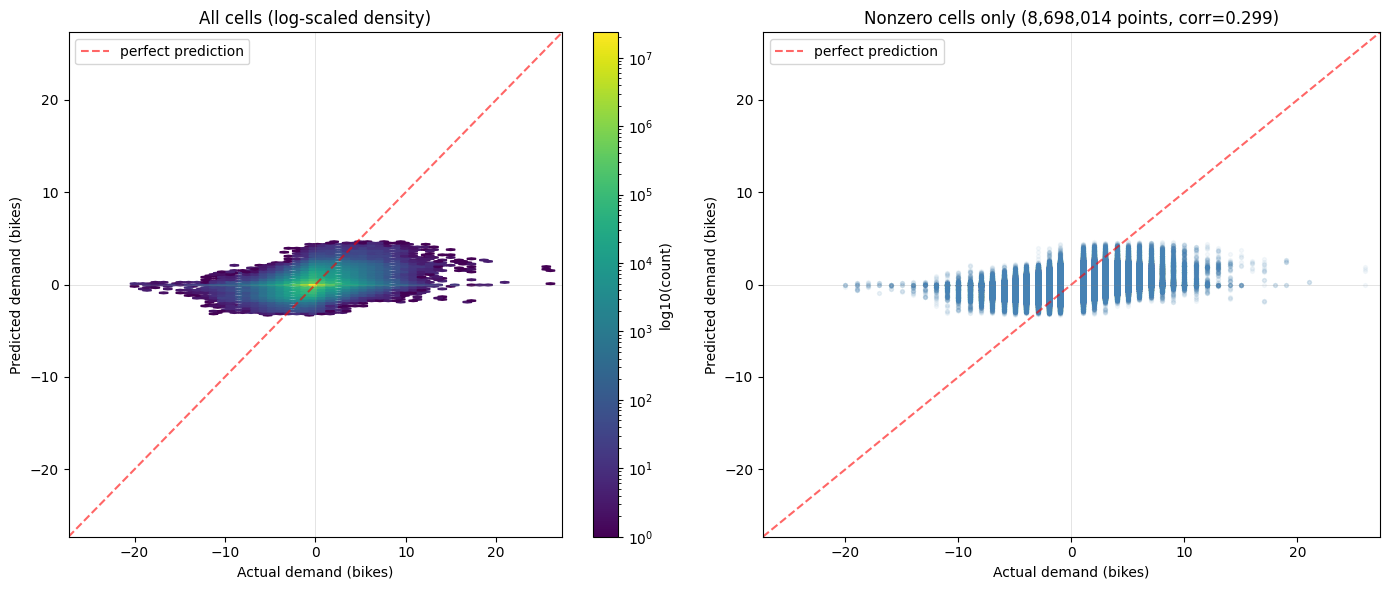

In [30]:
# Load the TWO-STAGE checkpoint, not the old one
model.load_state_dict(torch.load("best_model_flow_k5_twostage.pt", map_location=device))

edge_data = edge_data.squeeze(1) if edge_data.dim() == 2 else edge_data
edge_index = edge_index.to(device)
edge_data = edge_data.to(device)

import matplotlib.pyplot as plt
import numpy as np

model.eval()
all_preds_combined = []   # threshold-mode prediction (for direct comparison to old plots)
all_preds_logits   = []   # raw classifier logits
all_preds_magnitude = []  # raw regressor output
all_targets = []
all_masks = []

THRESHOLD = 0.4   # tune on validation later

with torch.no_grad():
    for x_b, y_b, m_b in test_loader:
        x_b = x_b.to(device)
        # get both heads
        logits, magnitude = model(x_b, edge_index, edge_data)
        p_nonzero = torch.sigmoid(logits)
        # threshold-mode combined prediction
        combined = torch.where(p_nonzero > THRESHOLD, magnitude, torch.zeros_like(magnitude))

        all_preds_combined.append(combined.cpu())
        all_preds_logits.append(logits.cpu())
        all_preds_magnitude.append(magnitude.cpu())
        all_targets.append(y_b)
        all_masks.append(m_b)

preds       = torch.cat(all_preds_combined, dim=0)
logits_all  = torch.cat(all_preds_logits, dim=0)
mag_all     = torch.cat(all_preds_magnitude, dim=0)
targets     = torch.cat(all_targets, dim=0)
masks       = torch.cat(all_masks, dim=0)

# Flatten with mask — same as before
preds_flat   = preds[masks].numpy()
targets_flat = targets[masks].numpy()
mag_flat     = mag_all[masks].numpy()
p_flat       = torch.sigmoid(logits_all)[masks].numpy()
print(f"Plotting {len(preds_flat):,} (station, timestep) pairs")


# 3. Two-panel plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: full distribution (hexbin handles density)
ax = axes[0]
hb = ax.hexbin(targets_flat, preds_flat, gridsize=50, bins='log', cmap='viridis', mincnt=1)
lim = max(abs(targets_flat).max(), abs(preds_flat).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'r--', alpha=0.6, label='perfect prediction')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Actual demand (bikes)')
ax.set_ylabel('Predicted demand (bikes)')
ax.set_title('All cells (log-scaled density)')
ax.legend(loc='upper left')
ax.axhline(0, color='gray', alpha=0.3, linewidth=0.5)
ax.axvline(0, color='gray', alpha=0.3, linewidth=0.5)
plt.colorbar(hb, ax=ax, label='log10(count)')

# Right: nonzero cells only — this is where the model is actually doing work
nz_mask = targets_flat != 0
ax = axes[1]
ax.scatter(targets_flat[nz_mask], preds_flat[nz_mask], alpha=0.05, s=8, color='steelblue')
nz_lim = max(abs(targets_flat[nz_mask]).max(), abs(preds_flat[nz_mask]).max()) * 1.05
ax.plot([-nz_lim, nz_lim], [-nz_lim, nz_lim], 'r--', alpha=0.6, label='perfect prediction')
ax.set_xlim(-nz_lim, nz_lim)
ax.set_ylim(-nz_lim, nz_lim)
ax.set_xlabel('Actual demand (bikes)')
ax.set_ylabel('Predicted demand (bikes)')
ax.set_title(f'Nonzero cells only ({nz_mask.sum():,} points)')
ax.legend(loc='upper left')
ax.axhline(0, color='gray', alpha=0.3, linewidth=0.5)
ax.axvline(0, color='gray', alpha=0.3, linewidth=0.5)

# correlation in the title
from scipy.stats import pearsonr
corr, _ = pearsonr(targets_flat[nz_mask], preds_flat[nz_mask])
ax.set_title(f'Nonzero cells only ({nz_mask.sum():,} points, corr={corr:.3f})')

plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

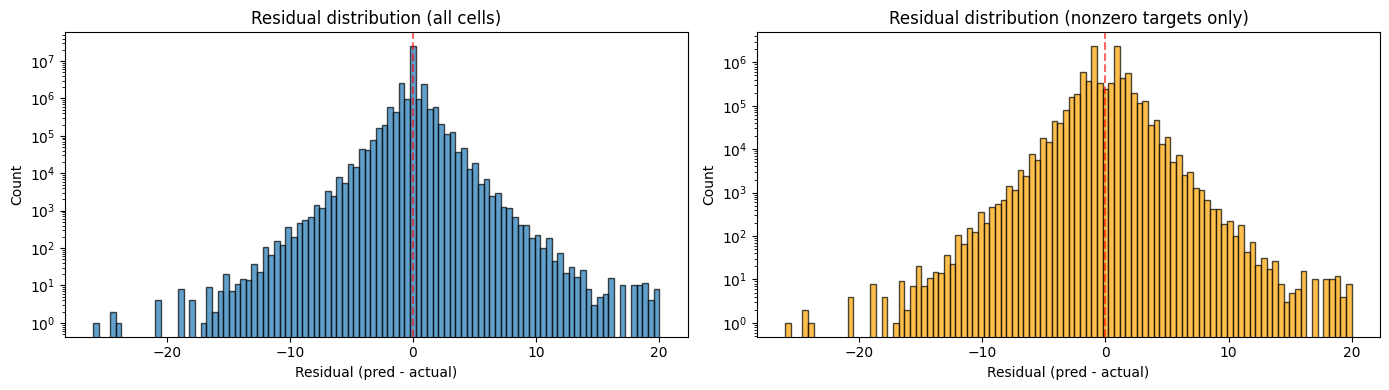

In [28]:
residuals = preds_flat - targets_flat
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Residual (pred - actual)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual distribution (all cells)')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.6)
axes[0].set_yscale('log')

axes[1].hist(residuals[targets_flat != 0], bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Residual (pred - actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution (nonzero targets only)')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.6)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('residuals.png', dpi=120, bbox_inches='tight')
plt.show()

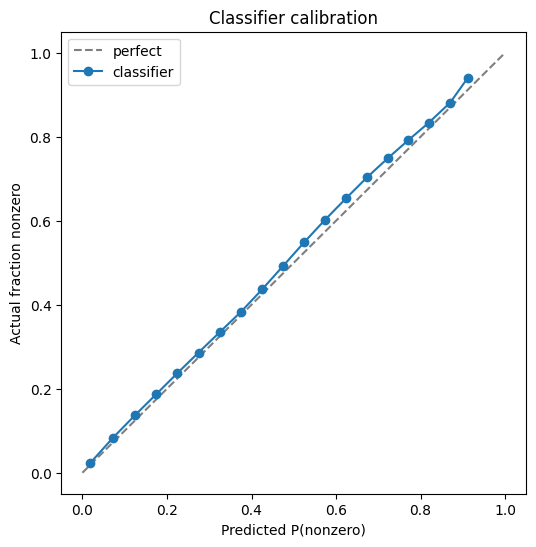

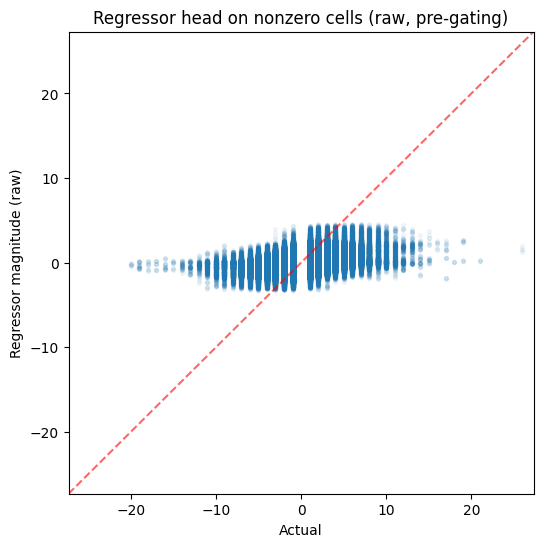

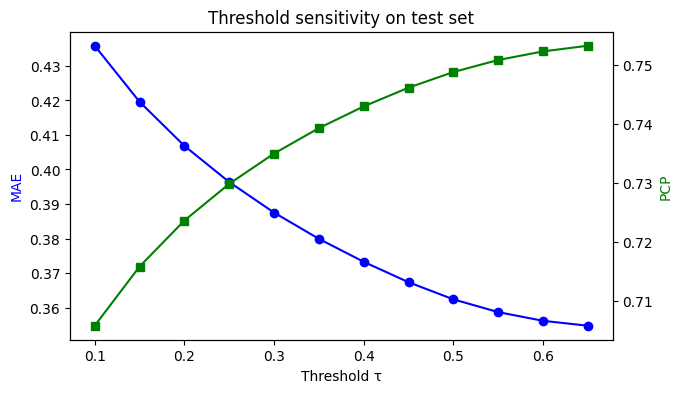

In [29]:
# 1. Classifier calibration: how well does P(nonzero) match actual nonzero rate?
from sklearn.calibration import calibration_curve
y_binary = (targets_flat != 0).astype(int)
prob_true, prob_pred = calibration_curve(y_binary, p_flat, n_bins=20)
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
plt.plot(prob_pred, prob_true, marker='o', label='classifier')
plt.xlabel('Predicted P(nonzero)')
plt.ylabel('Actual fraction nonzero')
plt.title('Classifier calibration')
plt.legend()
plt.savefig('classifier_calibration.png', dpi=120, bbox_inches='tight')
plt.show()

# 2. Regressor performance on nonzero cells alone — does it capture the tails?
nz = targets_flat != 0
plt.figure(figsize=(6, 6))
plt.scatter(targets_flat[nz], mag_flat[nz], alpha=0.05, s=8)
lim = max(abs(targets_flat[nz]).max(), abs(mag_flat[nz]).max()) * 1.05
plt.plot([-lim, lim], [-lim, lim], 'r--', alpha=0.6)
plt.xlim(-lim, lim); plt.ylim(-lim, lim)
plt.xlabel('Actual'); plt.ylabel('Regressor magnitude (raw)')
plt.title('Regressor head on nonzero cells (raw, pre-gating)')
plt.savefig('regressor_only.png', dpi=120, bbox_inches='tight')
plt.show()

# 3. Threshold sweep: how does choice of threshold affect MAE / PCP?
from collections import defaultdict
results = defaultdict(list)
for tau in np.arange(0.1, 0.7, 0.05):
    combined = np.where(p_flat > tau, mag_flat, 0.0)
    mae = np.abs(combined - targets_flat).mean()
    pcp = (np.round(combined) == targets_flat).mean()
    results['tau'].append(tau)
    results['mae'].append(mae)
    results['pcp'].append(pcp)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
ax1.plot(results['tau'], results['mae'], 'b-o', label='MAE')
ax2.plot(results['tau'], results['pcp'], 'g-s', label='PCP')
ax1.set_xlabel('Threshold τ')
ax1.set_ylabel('MAE', color='b'); ax2.set_ylabel('PCP', color='g')
ax1.set_title('Threshold sensitivity on test set')
plt.savefig('threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()